# Импорт библиотек

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns

# Загрузка датасета

In [39]:
df = sns.load_dataset("titanic")

df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


Проверка на пропущенные данные

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


В исходном датасете есть пропущенные данные
~200 в колонке age
~700 в колонке deck
2 в колонках embarked и embark town(в одних и тех же строках т.к. колонки одинаковы по смыслу)

Проверка на дубликаты

In [42]:
print(len(df.drop_duplicates()))
df = df.drop_duplicates()
df = df.reset_index(drop=True)

784


В датасете 107 дублирующихся строк

# Обработка пропусков

In [45]:
df['deck'] = df['deck'].cat.add_categories('Unknown')
df['deck'] = df['deck'].fillna('Unknown')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,Unknown,Queenstown,no,False
780,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
781,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,Unknown,Southampton,no,False
782,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


Удалять признак deck не стоит, хотя в нем много пропущенных данных, потому что расположение палубы сильно влияет на выживаемость. Можно попробовать восстановить данные на основе стоимости билета и класса или просто заменить NaN на Unknown.
Можно удалить строки в которых пропущены embarked и embark_town, потому что их всего 2 и удаление не сильно отразится на объеме данных.
Удалять колонку age нельзя, нужно ее восстанавливать. Например, опираясь на медианный возраст мужчин и женщин на борту, а так же колонку who(с ее помощью можно отделить детей от взрослых).

# Статистика для числовых признаков

In [32]:
df['age'].describe()

count    678.000000
mean      29.869351
std       14.759076
min        0.420000
25%       20.000000
50%       28.250000
75%       39.000000
max       80.000000
Name: age, dtype: float64

In [33]:
df['age'].median()

np.float64(28.25)

In [34]:
df['fare'].describe()

count    784.000000
mean      34.711740
std       52.160151
min        0.000000
25%        8.050000
50%       15.900000
75%       34.109350
max      512.329200
Name: fare, dtype: float64

In [35]:
df['fare'].median()

np.float64(15.9)

# Визуализация данных

Распределение пассажиров по классам билета + соотношение выживших в каждом классе

<Axes: xlabel='pclass', ylabel='count'>

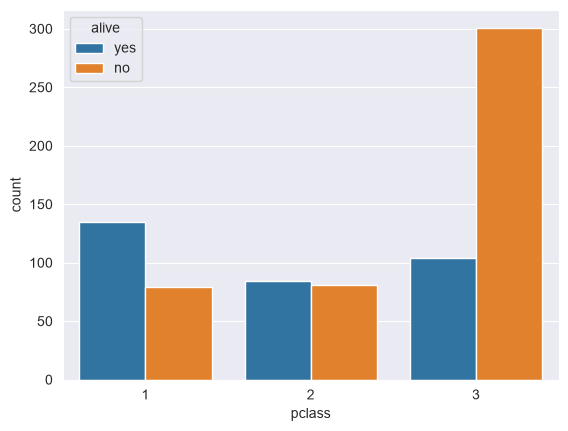

In [46]:
sns.countplot(data=df, x='pclass', hue='alive')

Распределение пассажиров по палубам

<Axes: xlabel='deck', ylabel='count'>

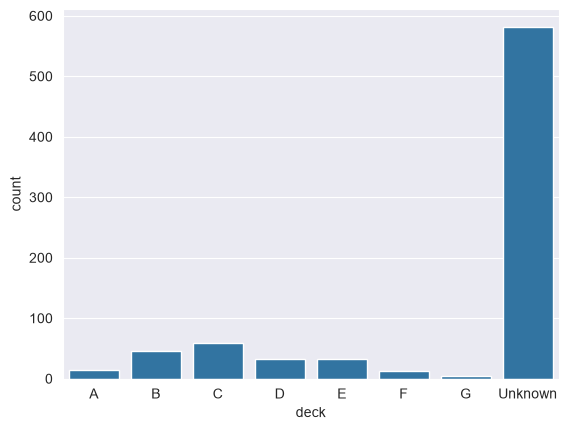

In [48]:
sns.countplot(data=df, x='deck')

Выжившие по возрастам

<Axes: xlabel='age', ylabel='Count'>

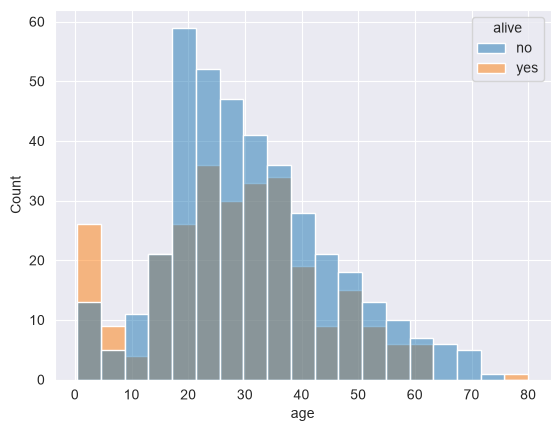

In [54]:
sns.histplot(data=df, x='age', hue='alive')

Выжившие по мужчинам, женщинам и детям

<Axes: xlabel='who', ylabel='count'>

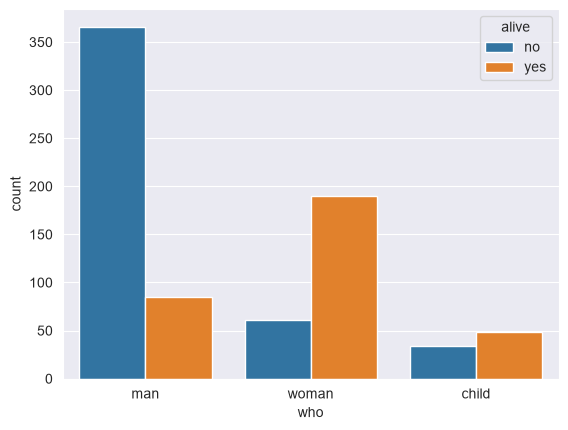

In [55]:
sns.countplot(data=df, x='who', hue='alive')

Выжившие по тем кто был один или с семьей на корабле

<Axes: xlabel='alone', ylabel='count'>

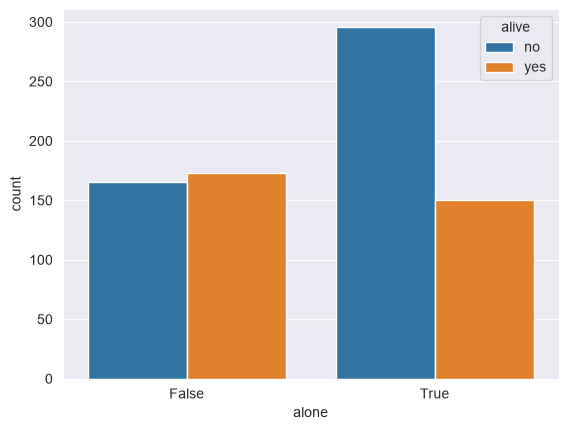

In [56]:
sns.countplot(data=df, x='alone', hue='alive')

Зависимость выживаемости от стоимости билета

<Axes: xlabel='fare', ylabel='Count'>

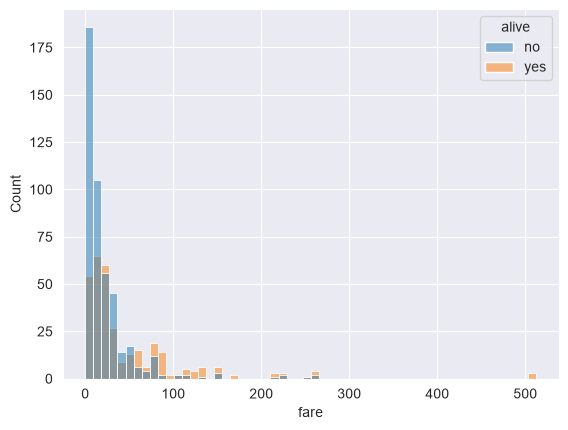

In [57]:
sns.histplot(data=df, x='fare', hue='alive')

За целевую переменную для обучения модели можно взять survived или alive(они дублируют информацию в разных типах данных), тогда оставшуюся колонку нужно будет удалить из датасета.
Признаками будут:
-pclass или class
-fare
-sex
-age
-who
-alone
-sibsp
-parch
-deck


Основной риск утечки данных в этом датасете это дубликаты, от них обязательно нужно избавиться.